## Weight update

Our main objective of backpropagation is to update learnable parameters of the network, i.e the weights.

Now, we update the weights as follows:

$new \space w = old \space w + \Delta w = old \space w + \eta (- \frac{\partial L}{\partial w})$ 

where, $\eta$ is the learning rate.

For example,

$$new \space w_0 = old \space w_0 + \Delta w_0 = old \space w_0 + \eta (- \frac{\partial L}{\partial w_0})$$
$$new \space w_1 = old \space w_1 + \Delta w_1 = old \space w_1 + \eta (- \frac{\partial L}{\partial w_1})$$

$$new \space w_2 = old \space w_2 + \Delta w_2 = old \space w_2 + \eta (- \frac{\partial L}{\partial w_2})$$



## Solution using numeric value

<div align="center">


<p>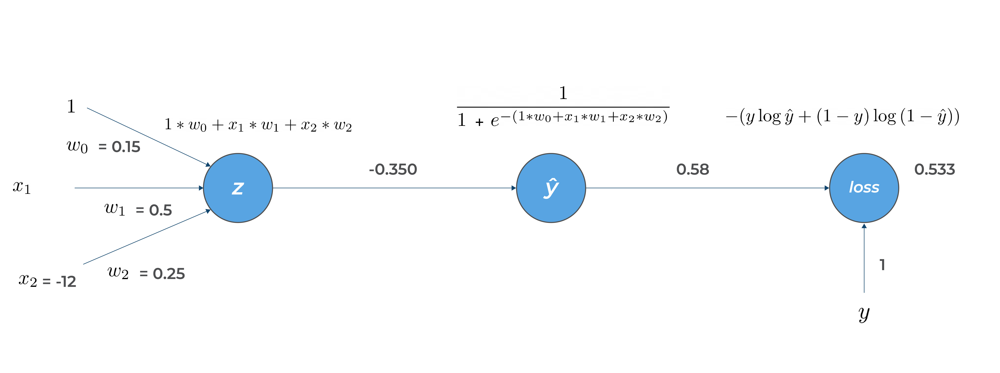</p>
</div>

$$z = 1 * w_0 + x_1 * w_1 + x_2 * w_2$$

$$\hat{y} = \frac{1}{1 + e^{-(1 * w_0 + x_1 * w_1 + x_2 * w_2)}}$$

$$L = loss = - ( y \log{\hat{y}} + (1 - y) \log{(1-\hat{y})})$$

Here, we have
$$x_1=5$$
$$x_2=-12$$
$$w_0=0.15$$
$$w_1=0.5$$
$$w_2=0.25$$
$$z=x_1*w_1+x_2*w_2+w_0=-0.350$$
$$\hat{y}=\frac{1}{1+e^{-z}}=0.58$$
$$loss=-(y\log{\hat{y}}+(1-y)\log{(1-\hat{y})})=0.533,when \space y=1$$

Now, applying chain rule,

<div align="center">


<p>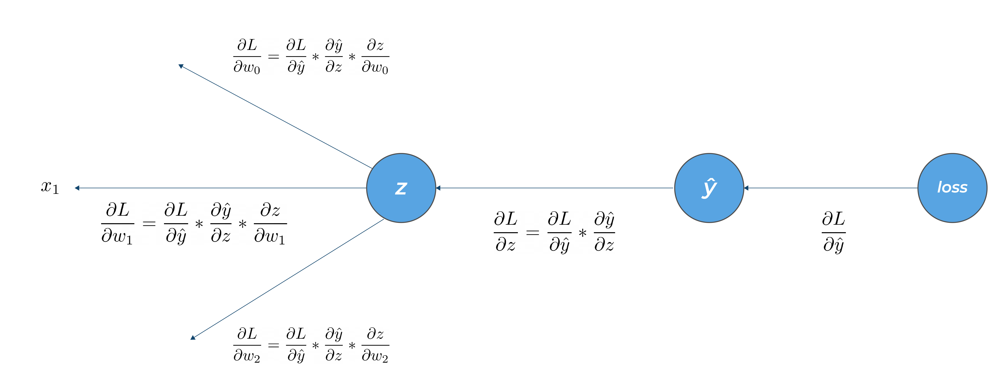</p>
</div>

$$\therefore\frac{\partial{L}}{\partial{\hat{y}}}=-(\frac{y}{\hat{y}}-\frac{(1-y)}{(1-\hat{y})})=1.7047$$

$$\therefore\frac{\partial{L}}{\partial{z}}=\frac{\partial{L}}{\partial{\hat{y}}}*\frac{\partial{\hat{y}}}{\partial{z}}=-(\frac{y}{\hat{y}}-\frac{(1-y)}{(1-\hat{y})})*\hat{y}*(1-\hat{y})=0.2425$$

$$\therefore\frac{\partial{L}}{\partial{w_0}}=\frac{\partial{L}}{\partial{\hat{y}}}*\frac{\partial{\hat{y}}}{\partial{z}}*\frac{\partial{z}}{\partial{w_0}}=0.2425$$

$$\therefore\frac{\partial{L}}{\partial{w_1}}=\frac{\partial{L}}{\partial{\hat{y}}}*\frac{\partial{\hat{y}}}{\partial{z}}*\frac{\partial{z}}{\partial{w_1}}=0.2524*0.5=0.1212$$

$$\therefore \frac{\partial{L}}{\partial{w_2}}=\frac{\partial{L}}{\partial{\hat{y}}}*\frac{\partial{\hat{y}}}{\partial{z}}*\frac{\partial{z}}{\partial{w_2}}=0.2524*0.25=0.0606$$

<div align="center">


<p>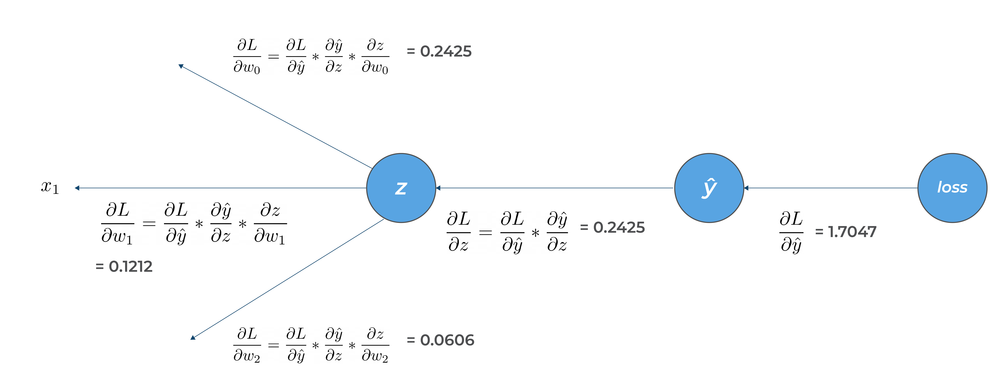</p>
</div>

Now, after calculation of change in loss with respect to weights, we update the weights in the direction of gradient descent inorder to decrease loss. So, we take negative of our gradient.

$$new \space w_0 =  0.15 + \eta (-0.2425)$$

$$new \space w_1 = 0.5 + \eta (-0.1212)$$

$$new \space w_2= 0.25 + \eta (-0.0606)$$
**where $\eta$ is learning rate which determines how fast we move**.(discussed in details in gradient descent chapter)

We apply this process of forward propagation, calculating gradient and updating weights iteratively until we minimize our loss successively.








## Backpropagation in multilayer network

Consider the network arcitecture described below (observe carefully all the notation and flow). Here, we are going to derive the backpropagation formula so we can directly use it in code. This portion is going to be quite mathematical.

_Here, super-script refers to the layer of neural network and sub-script to the node index. For example, $a^{(2)}_{1}$ refers to activation value of node 1 of layer 2._

<div align="center">


<p>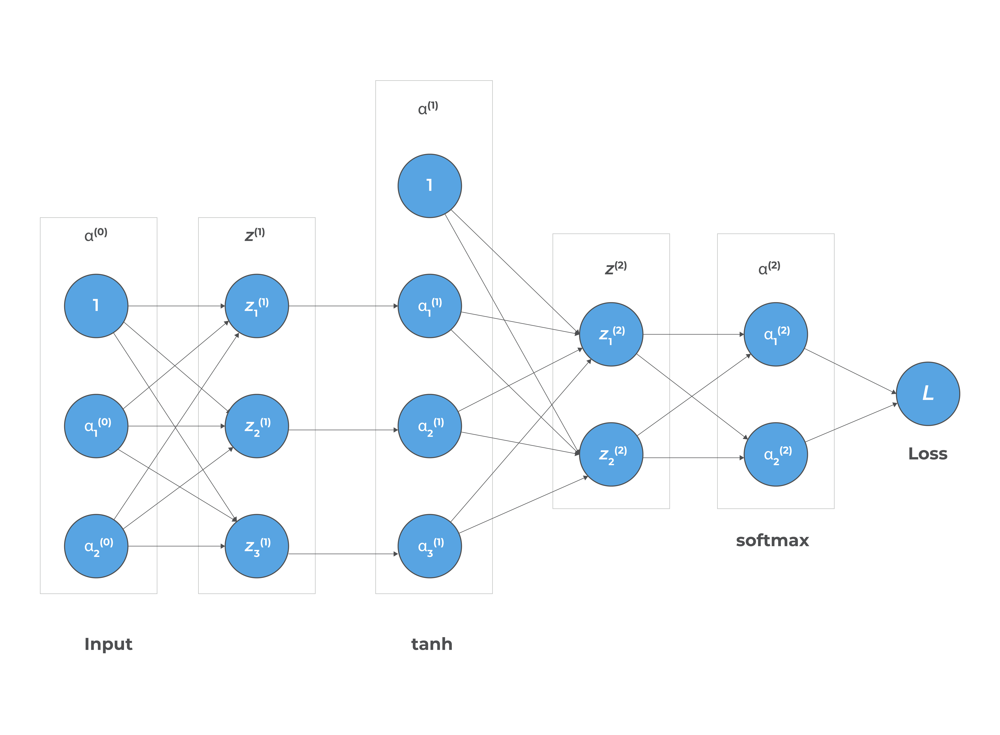</p>
</div>
We have,
$$ L = - \sum_i y \log (a_i^{(2)})$$
$$a_1^{(1)} = tanh (z_1^{(1)})$$
$$ a_1^{(2)} = \frac{e^{z_1^{(2)}}}{e^{z_1^{(2)}} + e^{z_2^{(2)}}} $$

After the forward propagation we will calculate the loss. After calculating the loss, we have to propagate the loss backward in order to adjust weights or parameters which will result in decrease in loss in next forward propagation.

_Let's look backpropagation more carefully in the softmax layer._



<p>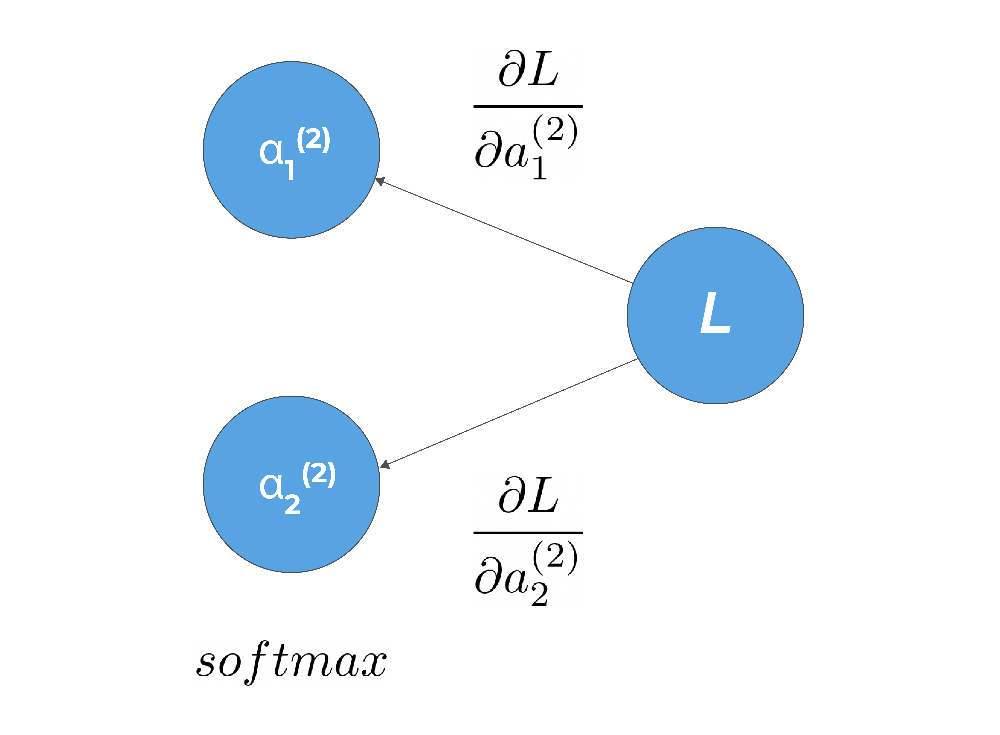</p>

Here, $\frac{\partial L}{\partial a^{(2)}_{1}}$ and $\frac{\partial L}{\partial a^{(2)}_{2}}$ are local gradients at node $L$.

$$\frac{\partial L}{\partial a^{(2)}_{1}}=-{y}_{1}\left[\frac{\left({a}^{(2)}_{1}\right)^{\prime}}{{a}^{(2)}_{1}}\right]=-{y}_{1}\left[\frac{1}{{a}^{(2)}_{1}}\right]$$

$$\frac{\partial L}{\partial a^{(2)}_{2}}=-{y}_{2}\left[\frac{\left({a}^{(2)}_{2}\right)^{\prime}}{{a}^{(2)}_{2}}\right]=-{y}_{2}\left[\frac{1}{{a}^{(2)}_{2}}\right]$$

*Above equation can be written in vector as,*


$$\frac{\partial L}{\partial \mathbf{(a^2)} }=-\mathbf{y}\left[\frac{1}{\mathbf{(a^2)}}\right]$$


*Where $\mathbf{y}$ is one hot encoded vector an $\mathbf{a^2 }$ is value of softmax layer*

Now, let's backpropagate one layer back from softmax layer.

**Note: Observe the connection to softmax layer, since softmax needs logits value of all nodes from previous layer.**



<p>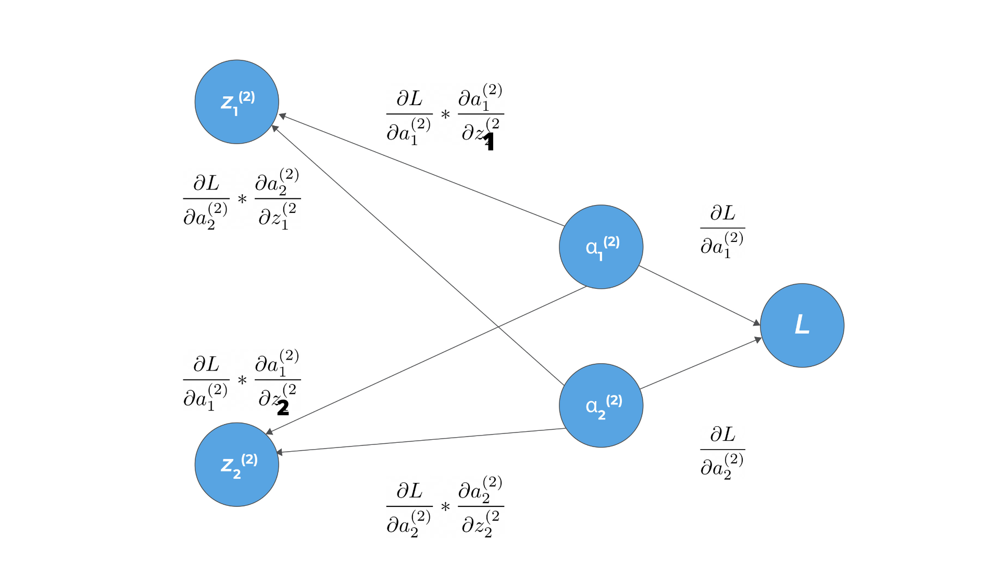</p>

Here,$\frac{\partial a^{(2)}_{1}}{\partial z^{(2)}_{1}}$ and $\frac{\partial a^{(2)}_{1}}{\partial z^{(2)}_{2}}$
 are local gradient for node $a^{(2)}_1$.similaryly,$\frac{\partial a^{(2)}_{2}}{\partial z^{(2)}_{1}}$ and $\frac{\partial a^{(2)}_{2}}{\partial z^{(2)}_{2}}$ are local gradient at node $a^{(2)}_2$.




$$\frac{\partial a^{(2)}_{1}}{\partial z^{(2)}_{1}}=\frac{\partial}{\partial z^{(2)}_{1}} \cdot \frac{e^{z^{(2)}_{1}}}{e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}}}=\dfrac {(e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}})e^{z^{(2)}_{1}}-e^{z^{(2)}_{1}}e^{z^{(2)}_{1}}}{(e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}})^2}=\dfrac {e^{z^{(2)}_{1}}e^{z^{(2)}_{2}}}{(e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}})^2}=\frac{e^{z^{(2)}_{1}}}{e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}}}(1-\dfrac{e^{z^{(2)}_{1}}}{e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}}})=a^{(2)}_1(1-a^{(2)}_1)$$




$$\frac{\partial a^{(2)}_{1}}{\partial z^{(2)}_{2}}=\frac{\partial}{\partial z^{(2)}_{2}} \cdot \frac{e^{z^{(2)}_{1}}}{e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}}}=\dfrac {(e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}}).0-e^{z^{(2)}_{1}}e^{z^{(2)}_{2}}}{(e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}})^2})=-\dfrac{e^{z^{(2)}_{1}}}{e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}}}.\dfrac{e^{z^{(2)}_{2}}}{e^{z^{(2)}_{1}}+e^{z^{(2)}_{2}}}=-a^{(2)}_1.a^{(2)}_2$$



Similarly,

$$\frac{\partial a^{(2)}_{2}}{\partial z^{(2)}_{1}}=-a^{(2)}_1.a^{(2)}_2$$

$$\frac{\partial a^{(2)}_{2}}{\partial z^{(2)}_{2}}=a^{(2)}_2(1-a^{(2)}_2)$$

Here, In forward propagation figure, when we have connection of single node to multiple node in next layer (i.e layer $a^{(1)}$, $z^{(2)}$, we ignore $a^{(0)}$ since it is an input layer) than on backpropagation we will have multiple backprop path. In this case we add all the gradient values comming from the path. 

Visually we can see below for  $z^{(2)}_1$,



<p>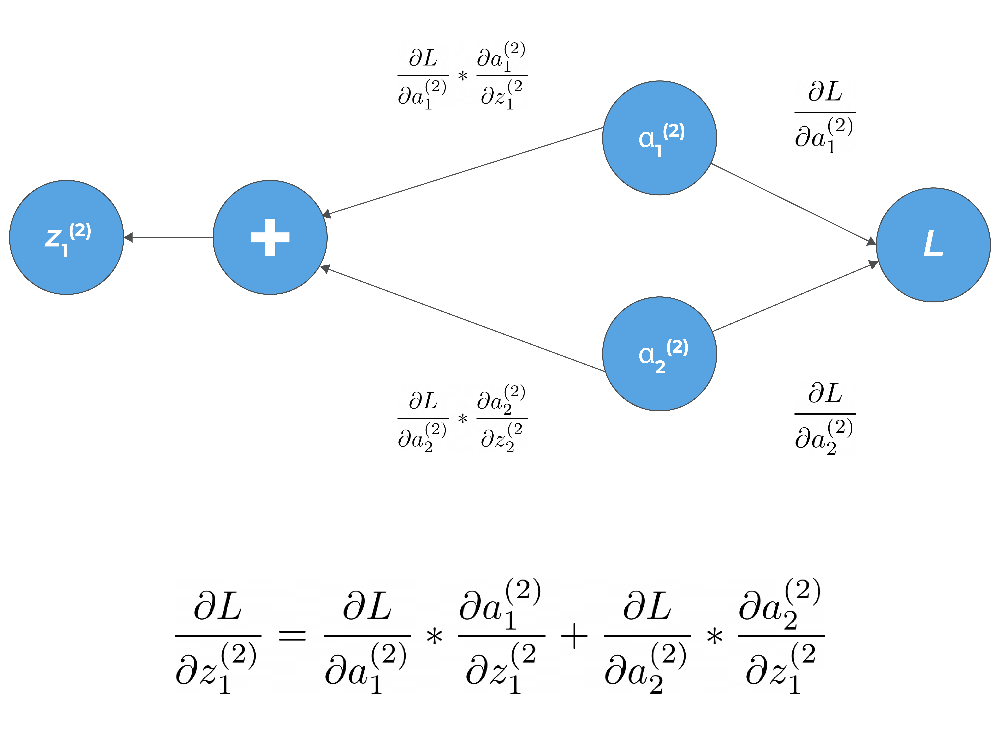</p>

## Now,
##  $\frac{\partial L}{\partial z^{(2)}_{1}}=\frac{\partial L}{\partial a^{(2)}_{1}}*\frac{\partial a^{(2)}_1}{\partial z^{(2)}_{1}}+\frac{\partial L}{\partial a^{(2)}_{2}}*\frac{\partial a^{(2)}_2}{\partial z^{(2)}_{1}}$
## $=-{y}_{1}[\frac{1}{a^{(2)}_{1}}]*a^{(2)}_1(1-a^{(2)}_1)+(-{y}_{2}[\frac{1}{a^{(2)}_{2}}])*-a^{(2)}_1.a^{(2)}_2$
## $ =-{y}_{1}(1-a^{(2)}_1)+{y}_{2}a^{(2)}_1$
## $=-{y}_{1}+({y}_{1}+{y}_{2})a^{(2)}_1$ 
 **since ${y}$ is one-hot vector ,sum of its element is 1**
## $=a^{(2)}_1-{y}_{1}$


##  $\frac{\partial L}{\partial z^{(2)}_{2}}=\frac{\partial L}{\partial a^{(2)}_{1}}*\frac{\partial a^{(2)}_1}{\partial z^{(2)}_{2}}+\frac{\partial L}{\partial a^{(2)}_{2}}*\frac{\partial a^{(2)}_2}{\partial z^{(2)}_{2}}$
## $=-{y}_{1}[\frac{1}{a^{(2)}_{1}}]*(-a^{(2)}_1.a^{(2)}_2)+(-{y}_{2}[\frac{1}{a^{(2)}_{2}}])*a^{(2)}_2(1-a^{(2)}_2)$
## $ ={y}_{1}a^{(2)}_2-{y}_{2}+{y}_{2}a^{(2)}_2$
## $=({y}_{1}+{y}_{2})a^{(2)}_2-{y}_{2}$ 
 **since ${y}$ is one-hot vector ,sum of its element is 1**
## $=a^{(2)}_2-{y}_{2}$

## Hence $\frac{\partial L}{\partial \mathbf z^{(2)}}$ can be expressed in vector form as ,$$\frac{\partial L}{\partial \mathbf z^{(2)}}=\begin{bmatrix}
\frac{\partial L}{\partial z^{(2)}_1} \\ 
\frac{\partial L}{\partial z^{(2)}_2} \\
\end{bmatrix}
=\begin{bmatrix}
a^{(2)}_1-{y_1} \\ 
a^{(2)}_2-{y_1} \\
\end{bmatrix}=[\mathbf a^{(2)}-{\mathbf y}]$$


## $\delta_{2}=\frac{\partial L}{\partial \mathbf z^{(2)}}$


Like $\delta_{2}$ we accumulate error at every layer for reusability.

## $\frac{\partial L}{\partial \it w^{(2)}}  = \frac{\partial L}{\partial \mathbf a^{(2)}}*\frac{\partial \mathbf a^{(2)}}{\partial \mathbf z^{(2)}}*\frac{\partial \mathbf z^{(2)}}{\partial \it w^{(2)}}$
## $\frac{\partial L}{\partial \it w^{(2)}}  = \frac{\partial L}{\partial \mathbf z^{(2)}}*\frac{\partial \mathbf z^{(2)}}{\partial \it w^{(2)}}$
## $\frac{\partial L}{\partial \it w^{(2)}}  =\delta_{2} *\frac{\partial \mathbf z^{(2)}}{\partial \it w^{(2)}}$

## $\frac{\partial L}{\partial \it W^{(2)}}={\mathbf a^{(1)}}^{T} \delta_{2}$

**Here, we have computed change in loss w.r.t change in $w^{(2)}$, so now we update our old value of $w^{(2)}$ as,**


**new $\it{w^{(2)}}$= old $\it w^{(2)}$ +$\eta$(-$\frac{\partial L}{\partial \it W^{(2)}}$)**


since, we still have more parameters left to update (i.e $w^{(1)}$
) we backpropagate further


## for hidden layer with tanh 

## $ \frac {\partial tanh(z)}{\partial {z}}= \frac {\partial \frac {sinh(z)}{cosh(z)}}{\partial {z}}= \frac{cosh(z)\frac {\partial sinh(z)}{\partial z}-sinh(z) \frac {\partial cosh(z)}{\partial z}}{{cosh^2(z)}} =\frac {cosh^2(z) -sinh^2(z)}{cosh^2(z)}=  (1-tanh^2(z))$

## **so**, 
## $\frac {\partial {\mathbf a^{(1)}}}{\partial {\mathbf z^{(1)}}}= (1-tanh^2(\mathbf z^{(1)}))$




<p>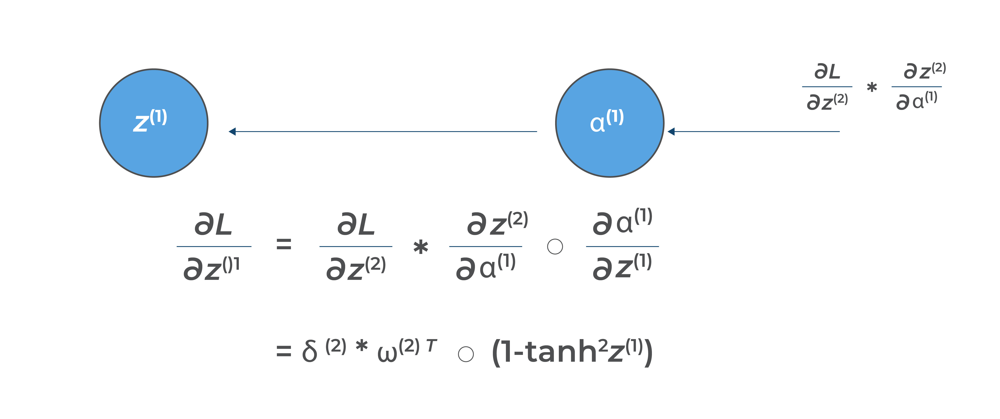</p>



## $ \frac {\partial {L}}{\partial {\mathbf z^{(1)}}} =\frac {\partial {L}}{\partial {\mathbf z^{(2)}}}*\frac {\partial {\mathbf z^{(2)}}}{\partial {\mathbf a^{(1)}}}*\frac {\partial {\mathbf a^{(1)}}}{\partial {\mathbf z^{(1)}}} $
## $\delta_{1}=\frac {\partial {L}}{\partial {\mathbf z^{(1)}}}=\left(1-\tanh ^{2} \mathbf z^{(1)}\right) \circ \delta_{2} \it W_{2}^{T}$

In above network Architecture figure there is no connection of bias node $a^{(1)}_0$ to network backward it. So, when we backpropagate $w^{(2)}$ we strip bias and backpropagate i,e since $w^{(2)}$ is of shape $4*2$ , first row is bias value for $z^{(2)}_1$ and $z^{(2)}_2$ we strip it out and backpropagate rest of the rows.


**Note: since there is one-to-one connection between $z^{(1)}$ and $a^{(1)}$ we perform elementwise operation in forward propagation and also in backpropagation from $a^{(1)}$ to $z^{(1)}$ there is one-to-one path as shown below in figure,**



<p>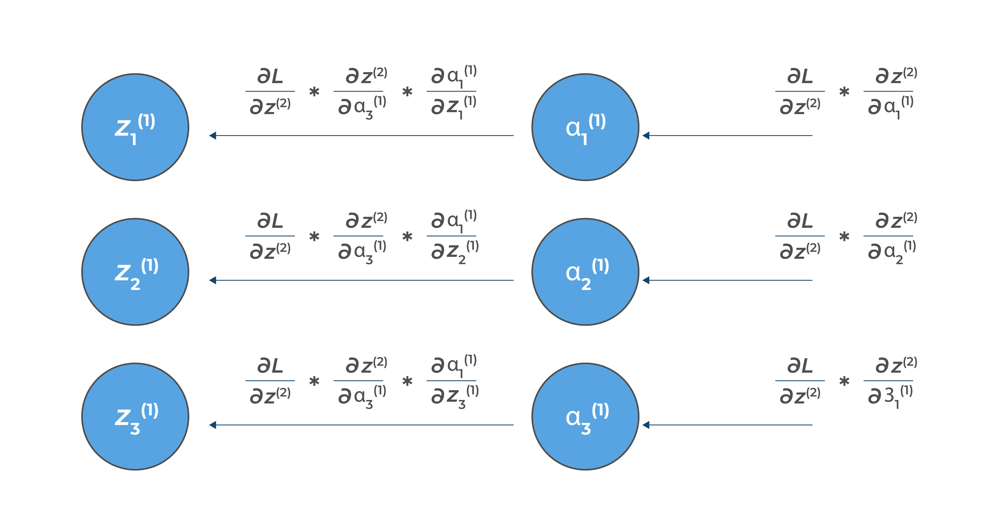</p>


## $\frac{\partial L}{\partial \it W^{(1)}}=\frac {\partial {L}}{\partial {\mathbf z^{(1)}}}*\frac {\partial {\mathbf z^{(1)}}}{\partial {\it w^{(1)}}} =x^{T} \delta_1$

**Here, we have computed change in loss w.r.t change in $w^{(1)}$, so now we update our old value of $w^{(1)}$ as,**


**new $\it w^{(1)}$= old $\it w^{(1)}$ +$\eta$(-$\frac{\partial L}{\partial \it W^{(1)}}$)**


Now, we have updated all the parameters in our network. So we forward propagate with updated parameters, calulate loss then again backpropagate as discussed above, update weights and repeat2 this process for several times until loss decreases successively.

Here, the major limitations of backpropagation on a neural network is the convergence rate is slow and highly dependent upon the learning rate. It also suffers from local minima problem too.



## Implementing Backpropagation

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets as dataset

In [54]:
X,y = dataset.make_blobs(n_samples=200, centers=2, n_features=2, center_box=(3,10), random_state=99)

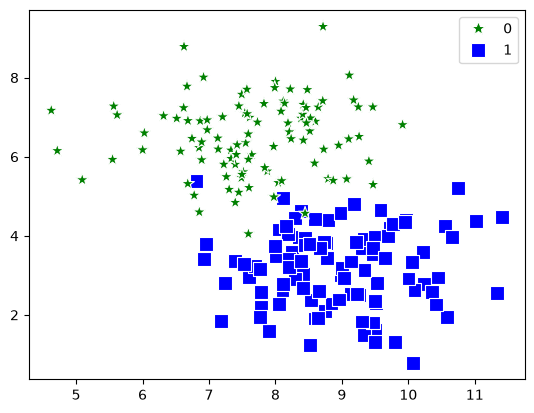

In [55]:
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y,
    style=y,
    markers={0: "*", 1: "s"},
    palette={0: "g", 1: "b"},
    s=100,
)
plt.show()

### Network Architecture

Let us consider a logistic regression with two inputs variable $x_1$ and $x_2$. In graph below $z$ is a weighted sum of input plus bias. $\hat{y}$ is the output of the sogmoid function and $y$ is the true label for training example. $y$ and $\hat{y}$ are then passed to a binary cross entropy loss function to calculate the loss.



<p>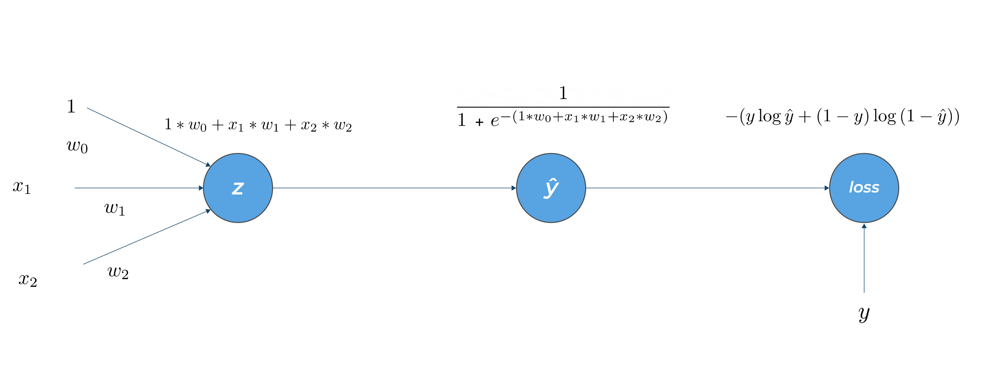</p>

We have,

$$z = 1 * w_0 + x_1 * w_1 + x_2 * w_2$$

$$\hat{y} = \frac{1}{1 + e^{-(1 * w_0 + x_1 * w_1 + x_2 * w_2)}}$$

$$L = loss = - ( y \log{\hat{y}} + (1 - y) \log{(1-\hat{y})})$$





In [56]:
# hyperparams
lr = 0.001


In [57]:
# Forward Propogation

def linear(X, w):
    return np.matmul(X, w)

sigmoid = lambda z : 1 / ( 1+ np.exp(-z))

def calc_loss(y_hat, y):
    loss = 0
    for actual, pred in zip(y, y_hat):
        loss += -(actual * np.log(pred) + (1-actual) * np.log(1- pred))

    mean_loss = loss[0] / len(y)
    return float(mean_loss)

In [58]:
X_with_bias = np.concat(
    ( np.ones((X.shape[0], 1)), X ),
    axis = 1
)

w = np.random.rand(3,1)

In [59]:
z = linear(X_with_bias, w)

In [60]:
y_hat = sigmoid(z)

In [61]:
loss = calc_loss(y_hat, y)

In [62]:
loss

3.8194112994905947

**Backpropagation**

Backpropagation and chainrule seems as below,

<p>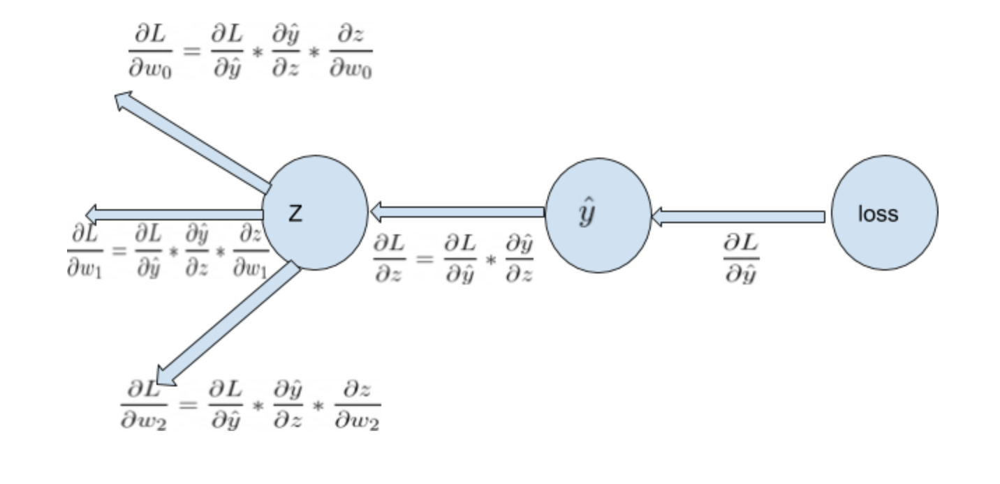</p>


from above reading material,we have derived formulas , let's state it and apply in code



$$\frac{\partial{L}}{\partial{w_0}}=\frac{\partial{L}}{\partial{\hat{y}}}*\frac{\partial{\hat{y}}}{\partial{z}}*\frac{\partial{z}}{\partial{w_0}}=-(\frac{y}{\hat{y}}-\frac{(1-y)}{(1-\hat{y})})*\hat{y}(1-\hat{y})*1$$

$$\frac{\partial{L}}{\partial{w_1}}=\frac{\partial{L}}{\partial{\hat{y}}}*\frac{\partial{\hat{y}}}{\partial{z}}*\frac{\partial{z}}{\partial{w_1}}=-(\frac{y}{\hat{y}}-\frac{(1-y)}{(1-\hat{y})})*\hat{y}(1-\hat{y})*x_1$$

$$ \frac{\partial{L}}{\partial{w_2}}=\frac{\partial{L}}{\partial{\hat{y}}}*\frac{\partial{\hat{y}}}{\partial{z}}*\frac{\partial{z}}{\partial{w_2}}=-(\frac{y}{\hat{y}}-\frac{(1-y)}{(1-\hat{y})})*\hat{y}(1-\hat{y})*x_2$$


**Vectorization**
$$\frac{\partial{L}}{\partial{w}}=\frac{\partial{L}}{\partial{\hat{y}}}*\frac{\partial{\hat{y}}}{\partial{z}}*\frac{\partial{z}}{\partial{w}}=\frac{\partial{L}}{\partial{z}}*\frac{\partial{z}}{\partial{w}}={x}^\intercal*(-(\frac{y}{\hat{y}}-\frac{(1-y)}{(1-\hat{y})})) \circ \hat{y}(1-\hat{y})$$



Here,
 for 200 training example $ \frac{\partial{L}}{\partial{\hat{y}}}$ will be of shape $200\times1$ and $ \frac{\partial{\hat{y}}}{\partial{z}}$ will also be of shape $200\times1$

$$ \frac{\partial{L}}{\partial{z}}=\frac{\partial{L}}{\partial{\hat{y}}}*\frac{\partial{\hat{y}}}{\partial{z}} $$

Since, there is one-to-one mapping between $z$, $\hat{y}$ and $L$ we compute elementwise multipication between $ \frac{\partial{L}}{\partial{\hat{y}}}$ and $ \frac{\partial{\hat{y}}}{\partial{z}}$, so the shape of $ \frac{\partial{L}}{\partial{z}}$ is $200\times1$. $x^\intercal$ is of the shape $3\times200$  so finally matrix multipication of $x^\intercal$ and $ \frac{\partial{L}}{\partial{z}}$ we gat $ \frac{\partial{L}}{\partial{w}}$ of shape $3\times1$.

 



In [63]:
# BAck Propogation

def backpropogation(x, y, epochs, w):
    history = []

    for i in range(epochs):
        # forward - > loss
        y_hat = sigmoid(linear(x, w))
        history.append(calc_loss(y_hat, y))

        # Backward
        dl_dyhat = -(y / y_hat - (1-y) / (1- y_hat))
        dyhat_dx = y_hat * (1- y_hat)

        dl_dw = np.matmul(x.T , (dl_dyhat * dyhat_dx))

        w = w - (lr * dl_dw )

        print(f"Loss at epoch {i} is {calc_loss(y_hat, y):.4f}")

    return w, history
        

In [64]:
y = y.reshape(-1,1)

In [65]:
model, history = backpropogation( X_with_bias, y, 50, w)

Loss at epoch 0 is 3.8194
Loss at epoch 1 is 0.4812
Loss at epoch 2 is 0.9749
Loss at epoch 3 is 1.6541
Loss at epoch 4 is 1.0945
Loss at epoch 5 is 1.2118
Loss at epoch 6 is 0.8061
Loss at epoch 7 is 0.7407
Loss at epoch 8 is 0.4692
Loss at epoch 9 is 0.3438
Loss at epoch 10 is 0.2160
Loss at epoch 11 is 0.1588
Loss at epoch 12 is 0.1365
Loss at epoch 13 is 0.1301
Loss at epoch 14 is 0.1279
Loss at epoch 15 is 0.1265
Loss at epoch 16 is 0.1254
Loss at epoch 17 is 0.1244
Loss at epoch 18 is 0.1234
Loss at epoch 19 is 0.1224
Loss at epoch 20 is 0.1215
Loss at epoch 21 is 0.1206
Loss at epoch 22 is 0.1197
Loss at epoch 23 is 0.1189
Loss at epoch 24 is 0.1181
Loss at epoch 25 is 0.1173
Loss at epoch 26 is 0.1165
Loss at epoch 27 is 0.1158
Loss at epoch 28 is 0.1151
Loss at epoch 29 is 0.1144
Loss at epoch 30 is 0.1138
Loss at epoch 31 is 0.1131
Loss at epoch 32 is 0.1125
Loss at epoch 33 is 0.1119
Loss at epoch 34 is 0.1113
Loss at epoch 35 is 0.1107
Loss at epoch 36 is 0.1102
Loss at epo

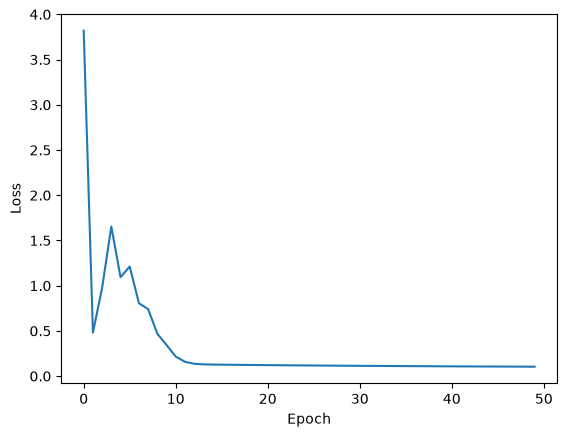

In [73]:
sns.lineplot(x=range(len(history)), y=history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [67]:
model

array([[ 0.70201257],
       [ 0.98804331],
       [-1.85111845]])

In [68]:
# Inference
y_hat = sigmoid(linear(X_with_bias, model))

In [69]:
pred = y_hat > 0.5
preds = pred.astype(int)
preds.flatten()

array([0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0])

In [70]:
y.flatten()

array([0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0])

In [71]:
from sklearn.metrics import classification_report

In [72]:
print(classification_report(y.flatten(), preds.flatten()))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       100
           1       0.97      0.98      0.98       100

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200

